<a href="https://colab.research.google.com/github/tiagoflorin/DataScience2/blob/Clase_1/Pr%C3%A1ctica_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tipos de Bases de datos


##1. Ejemplo NoSQL (Modelo de Documentos)

In [ ]:
!pip install mongomock pymongo

import mongomock
from pprint import pprint

# Creamos un cliente simulado (en memoria)
client = mongomock.MongoClient()
db = client["mi_tienda"]
productos = db["inventario"]

# Demostración de VARIEDAD DE MODELOS (Esquema flexible)
datos = [
    {"nombre": "Laptop", "precio": 1200, "especificaciones": {"ram": "16GB", "cpu": "i7"}},
    {"nombre": "Silla Ergonómica", "material": "Cuero", "colores": ["Negro", "Gris"]},
    {"nombre": "Teclado", "stock": 50, "inalambrico": True}
]

productos.insert_many(datos)

print("✅ Datos insertados en NoSQL (Documentos) con éxito:\n")
for doc in productos.find():
    pprint(doc)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 16.2 MB/s eta 0:00:00
✅ Datos insertados en NoSQL (Documentos) con éxito:

{'_id': ObjectId('696e99c6ff0a398b72cd0200'),
 'especificaciones': {'cpu': 'i7', 'ram': '16GB'},
 'nombre': 'Laptop',
 'precio': 1200}
{'_id': ObjectId('696e99c6ff0a398b72cd0201'),
 'colores': ['Negro', 'Gris'],
 'material': 'Cuero',
 'nombre': 'Silla Ergonómica'}
{'_id': ObjectId('696e99c6ff0a398b72cd0202'),
 'inalambrico': True,
 'nombre': 'Teclado',
 'stock': 50}


## 2. Ejemplo NewSQL (Estructura ACID y Escalabilidad)

In [ ]:
!pip install psycopg2-binary

import psycopg2

try:
    # Simulación de conexión
    # conn = psycopg2.connect("tu_url_de_cockroachdb")
    # cur = conn.cursor()

    print("--- Simulando Operación ACID en NewSQL ---")

    # SQL Estándar con integridad total
    crear_tabla = """
    CREATE TABLE IF NOT EXISTS cuentas (
        id INT PRIMARY KEY,
        balance DECIMAL
    );
    """

    # Transacción ACID: O se hace todo, o no se hace nada
    transferencia = """
    BEGIN;
    UPDATE cuentas SET balance = balance - 100 WHERE id = 1;
    UPDATE cuentas SET balance = balance + 100 WHERE id = 2;
    COMMIT;
    """

    print("Comando NewSQL listo: Se garantiza ACID aunque los datos estén en 100 servidores.")
    print(transferencia)

except Exception as e:
    print(f"Error: {e}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 37.9 MB/s eta 0:00:00
--- Simulando Operación ACID en NewSQL ---
Comando NewSQL listo: Se garantiza ACID aunque los datos estén en 100 servidores.

    BEGIN;
    UPDATE cuentas SET balance = balance - 100 WHERE id = 1;
    UPDATE cuentas SET balance = balance + 100 WHERE id = 2;
    COMMIT;
    


## Tipo de Base de Datos: NoSQL Orientada a Grafos


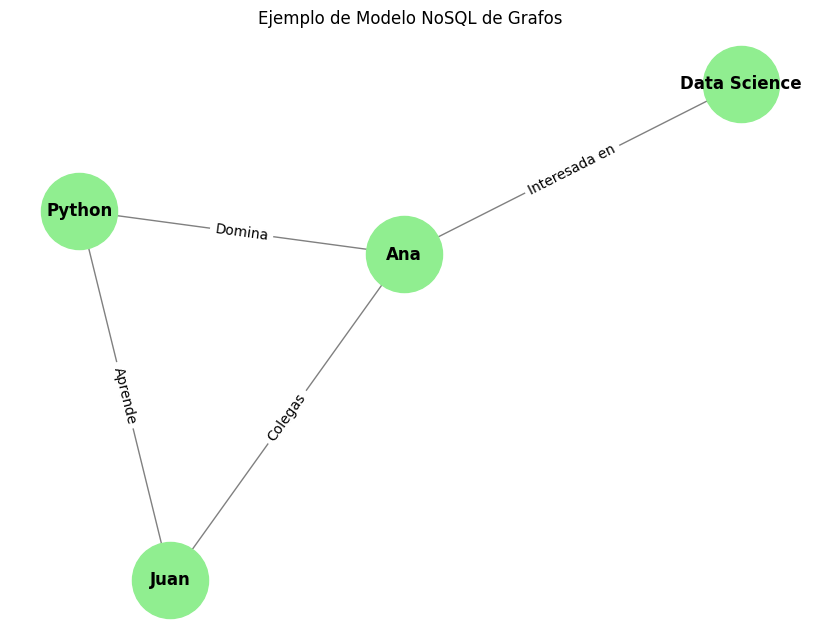


--- IDENTIFICACIÓN DEL MODELO ---
Tipo: NoSQL (Graph Database)
Componentes principales: Nodos (puntos) y Aristas (líneas que representan relaciones).
Uso ideal: Redes sociales, motores de recomendación, detección de fraudes.


In [ ]:
# 1. Instalamos y cargamos las librerías necesarias
import networkx as nx
import matplotlib.pyplot as plt

# 2. Creamos el objeto del Grafo
# Tipo de Base de Datos: NoSQL Orientada a Grafos
G = nx.Graph()

# 3. Añadimos los Nodos (Entidades)
# Imagina una red social o un sistema de recomendaciones
G.add_node("Ana", tipo="Persona")
G.add_node("Juan", tipo="Persona")
G.add_node("Python", tipo="Habilidad")
G.add_node("Data Science", tipo="Interés")

# 4. Añadimos las Aristas (Las relaciones, que son el corazón de este modelo)
G.add_edge("Ana", "Juan", relacion="Colegas")
G.add_edge("Ana", "Python", relacion="Domina")
G.add_edge("Juan", "Python", relacion="Aprende")
G.add_edge("Ana", "Data Science", relacion="Interesada en")

# 5. Visualización del Grafo
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G)  # Algoritmo para posicionar los nodos

# Dibujar nodos y etiquetas
nx.draw(G, pos, with_labels=True, node_color='lightgreen',
        node_size=3000, font_weight='bold', edge_color='gray')

# Dibujar las etiquetas de las relaciones (aristas)
edge_labels = nx.get_edge_attributes(G, 'relacion')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Ejemplo de Modelo NoSQL de Grafos")
plt.show()

print("\n--- IDENTIFICACIÓN DEL MODELO ---")
print("Tipo: NoSQL (Graph Database)")
print("Componentes principales: Nodos (puntos) y Aristas (líneas que representan relaciones).")
print("Uso ideal: Redes sociales, motores de recomendación, detección de fraudes.")

In [ ]:
import plotly.graph_objects as go
import networkx as nx

# --- 1. Configuración de Datos (Todo en Español y Expandido) ---

# Definimos listas de nodos por categoría (Hemos añadido más para soportar la densidad)
personas = ["Alicia", "Beto", "Carlos", "David", "Elena", "Fernando"]
lenguajes = ["Python", "JavaScript", "Rust", "Go", "SQL"]
proyectos = ["Sistema_IA", "App_Web", "Nodo_Blockchain", "Tienda_Online", "API_Pagos"]
infraestructura = ["AWS", "Google_Cloud", "Azure", "Servidor_Local"]
conceptos = ["Machine_Learning", "Ciberseguridad", "Backend", "Frontend"]

# Creamos el grafo
G = nx.Graph()

# Función auxiliar para añadir nodos rápidamente
def agregar_nodos(lista, grupo):
    for item in lista:
        G.add_node(item, grupo=grupo)

agregar_nodos(personas, "Persona")
agregar_nodos(lenguajes, "Lenguaje")
agregar_nodos(proyectos, "Proyecto")
agregar_nodos(infraestructura, "Infraestructura")
agregar_nodos(conceptos, "Concepto")

# Formato: (Origen, Destino, Tipo de Relación)
relaciones = [
    # Relaciones Personas - Tecnologías (Expertise)
    ("Alicia", "Python", "Experta en"), ("Alicia", "Rust", "Estudia"), ("Alicia", "Machine_Learning", "Especialista en"),
    ("Beto", "JavaScript", "Experto en"), ("Beto", "SQL", "Utiliza"), ("Beto", "Frontend", "Enfocado en"),
    ("Carlos", "Python", "Junior en"), ("Carlos", "JavaScript", "Aprende"), ("Carlos", "Backend", "Trabaja en"),
    ("David", "Rust", "Arquitecto de"), ("David", "Go", "Utiliza"), ("David", "Ciberseguridad", "Auditor de"),
    ("Elena", "Go", "Experta en"), ("Elena", "Python", "Utiliza"), ("Elena", "Backend", "Lidera"),
    ("Fernando", "SQL", "DBA de"), ("Fernando", "Azure", "Administra"),

    # Relaciones Personas - Proyectos (Roles)
    ("Alicia", "Sistema_IA", "Líder Técnica de"),
    ("Beto", "App_Web", "Desarrollador Principal de"),
    ("Carlos", "Sistema_IA", "Desarrollador de"), ("Carlos", "Tienda_Online", "Apoyo en"),
    ("David", "Nodo_Blockchain", "Arquitecto de"),
    ("Elena", "API_Pagos", "Líder de Proyecto"),
    ("Fernando", "Tienda_Online", "Responsable de Datos"),

    # Relaciones Personas - Personas (Social/Profesional)
    ("Alicia", "David", "Colega de"), ("Alicia", "Carlos", "Mentora de"),
    ("Beto", "Fernando", "Colabora con"),
    ("Elena", "Alicia", "Coordina con"),

    # Relaciones Proyectos - Infraestructura (Despliegue)
    ("Sistema_IA", "AWS", "Desplegado en"), ("Sistema_IA", "Google_Cloud", "Respaldo en"),
    ("App_Web", "Google_Cloud", "Alojado en"),
    ("Nodo_Blockchain", "AWS", "Corre en"), ("Nodo_Blockchain", "Azure", "Nodos secundarios en"),
    ("Tienda_Online", "Azure", "Desplegado en"),
    ("API_Pagos", "Servidor_Local", "Entorno de pruebas"), ("API_Pagos", "AWS", "Producción en"),

    # Relaciones Tecnología - Tecnología y Proyectos (Dependencias)
    ("Sistema_IA", "Python", "Escrito en"), ("Sistema_IA", "Machine_Learning", "Implementa"),
    ("App_Web", "JavaScript", "Escrito en"), ("App_Web", "SQL", "Conecta a"),
    ("Nodo_Blockchain", "Rust", "Núcleo en"), ("Nodo_Blockchain", "Ciberseguridad", "Requiere"),
    ("Tienda_Online", "JavaScript", "Frontend en"), ("Tienda_Online", "SQL", "Base de datos"),
    ("API_Pagos", "Go", "Escrito en"), ("API_Pagos", "SQL", "Transacciones en"),
    ("Python", "SQL", "Se integra con"),
    ("App_Web", "API_Pagos", "Consume servicio de"),
    ("Tienda_Online", "API_Pagos", "Depende de")
]

# Añadimos las aristas al grafo
for origen, destino, label in relaciones:
    # Añadimos la relación si ambos nodos existen (por seguridad)
    if origen in G.nodes and destino in G.nodes:
        G.add_edge(origen, destino, relacion=label)

# --- 2. Cálculo del Diseño (Layout) ---
print(f"Procesando grafo con {len(G.nodes())} nodos y {len(G.edges())} relaciones...")
# Usamos spring_layout con parámetros ajustados para alta densidad
# k: Distancia óptima entre nodos (mayor = más separado). Importante aumentarlo aquí.
# iterations: Más iteraciones para intentar desenredar el "hairball".
pos = nx.spring_layout(G, k=0.9, iterations=100, seed=42)


# --- 3. Preparación para Plotly ---

# Preparar Aristas (Líneas)
edge_x = []
edge_y = []
# Para grafos densos en Plotly, es difícil poner hover individual en cada línea eficientemente.
# Las líneas aquí representan la CONEXIÓN, el hover de los nodos dará el contexto.
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.8, color='#999999'), # Líneas más finas y grises para no saturar
    hoverinfo='none',
    mode='lines')

# Preparar Nodos (Puntos)
node_x = []
node_y = []
node_text = []
node_color = []

# Mapa de colores para las categorías
color_map = {
    "Persona": "#FF6B6B",   # Rojo suave
    "Lenguaje": "#4ECDC4",  # Turquesa
    "Proyecto": "#FFE66D",  # Amarillo
    "Infraestructura": "#1A535C", # Azul oscuro
    "Concepto": "#F7FFF7"   # Casi blanco
}

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

    # Creamos el texto que aparecerá al pasar el mouse
    grupo = G.nodes[node]['grupo']

    # Info básica del nodo
    hover_info = f"<b>{node}</b><br>Tipo: {grupo}<br><br>Conexiones:"

    # (Opcional) Añadir detalles de sus conexiones al hover del nodo
    # Esto ayuda a entender el grafo denso sin necesidad de etiquetas en las líneas
    for vecino in G.neighbors(node):
         rel_data = G.get_edge_data(node, vecino)
         rel_tipo = rel_data.get('relacion', 'Conectado a')
         hover_info += f"<br>- {rel_tipo} -> {vecino}"

    node_text.append(hover_info)
    node_color.append(color_map.get(grupo, 'grey'))

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    text=[node for node in G.nodes()], # Etiquetas visibles siempre
    textposition="top center",
    textfont=dict(size=10, color='darkgrey'), # Texto más pequeño y sutil
    hoverinfo='text',
    hovertext=node_text, # El texto rico en HTML que definimos arriba
    marker=dict(
        showscale=False,
        color=node_color,
        size=22, # Nodos ligeramente más pequeños para dejar espacio
        line_width=1,
        line_color='black'))

# --- 4. Renderizado de la Figura ---
fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title='<br>Grafo NoSQL Complejo: Ecosistema Tecnológico Denso',
                titlefont_size=16,
                showlegend=False,
                hovermode='closest',
                # Fondo oscuro para que resalten mejor los colores de esta red compleja
                plot_bgcolor='rgb(240,240,240)',
                margin=dict(b=20,l=5,r=5,t=50),
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                )

# Nota: En un grafo tan denso, usa el zoom y pasa el mouse sobre los nodos
# para entender las relaciones específicas.
fig.show()

Procesando grafo con 24 nodos y 49 relaciones...


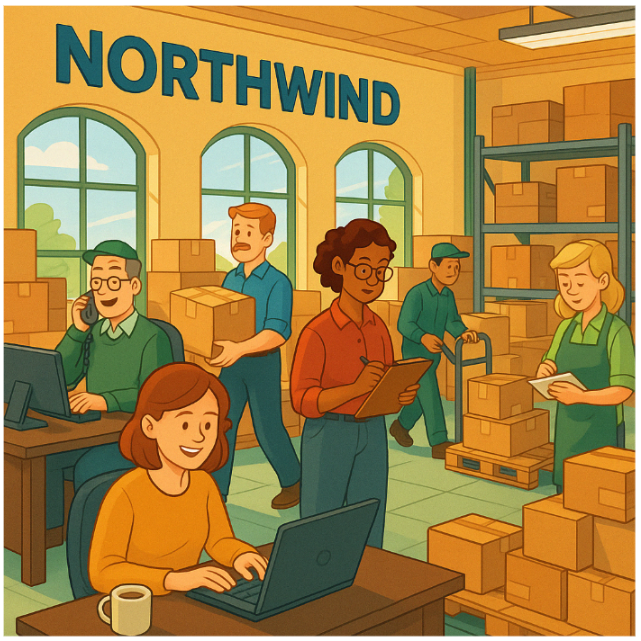

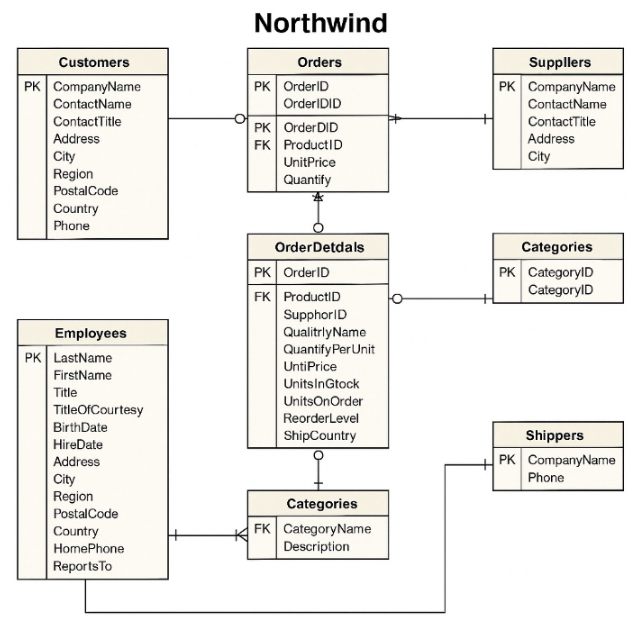

In [ ]:
# === Montar Google Drive ===
from google.colab import drive
drive.mount('/content/drive')

# === Instalar gdown (si no está instalado) ===
!pip install -q gdown

# === Descargar base de datos Northwind desde Google Drive ===
import gdown
import os

file_id = "1NdZopscZx_749_D7OfsADyAVrn7rpla1"
output_path = "/content/northwind.db"

gdown.download(
    url=f"https://drive.google.com/uc?id={file_id}",
    output=output_path,
    quiet=False
)

# === Verificar que el archivo existe ===
assert os.path.exists(output_path), "❌ Error: la base de datos no se descargó correctamente"

print("✅ Base de datos Northwind descargada en:", output_path)

Mounted at /content/drive


Downloading...
From: https://drive.google.com/uc?id=1NdZopscZx_749_D7OfsADyAVrn7rpla1
To: /content/northwind.db
100%|██████████| 24.7M/24.7M [00:00<00:00, 51.4MB/s]

✅ Base de datos Northwind descargada en: /content/northwind.db


In [ ]:
import sqlite3
conn = sqlite3.connect('northwind.db')

In [ ]:
import pandas as pd

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tablas encontradas:", tables['name'].tolist())


Tablas encontradas: ['Categories', 'sqlite_sequence', 'CustomerCustomerDemo', 'CustomerDemographics', 'Customers', 'Employees', 'EmployeeTerritories', 'Order Details', 'Orders', 'Products', 'Regions', 'Shippers', 'Suppliers', 'Territories']


# Tarea

1-Listar los nombres de los productos.

2-Mostrar los primeros 10 empleados.

3-Listar las órdenes realizadas por clientes de Alemania.

4-Obtener todos los productos con precio mayor a 20.

5-Mostrar los nombres y cargos de los empleados.

6-Listar los nombres de los clientes y su país.

7-Contar cuántos productos hay en total.

8-Mostrar los productos ordenados por precio de mayor a menor.

9-Mostrar las categorías de productos.

1-Listar los nombres de los productos.


In [ ]:
#Listar los nombres de los productos

pd.read_sql_query("SELECT ProductName FROM Products;", conn)

,ProductName
0,Chai
1,Chang
2,Aniseed Syrup
3,Chef Anton's Cajun Seasoning
4,Chef Anton's Gumbo Mix
...,...
72,Röd Kaviar
73,Longlife Tofu
74,Rhönbräu Klosterbier
75,Lakkalikööri


2-Mostrar los primeros 10 empleados.


In [ ]:
#Mostrar los primeros 10 empleados

pd.read_sql_query("SELECT * FROM Employees LIMIT 10;", conn)

,EmployeeID,LastName,FirstName,Title,TitleOfCourtesy,BirthDate,HireDate,Address,City,Region,PostalCode,Country,HomePhone,Extension,Photo,Notes,ReportsTo,PhotoPath
0,1,Davolio,Nancy,Sales Representative,Ms.,1968-12-08,2012-05-01,507 - 20th Ave. E.Apt. 2A,Seattle,North America,98122,USA,(206) 555-9857,5467,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Education includes a BA in psychology from Col...,2.0,http://accweb/emmployees/davolio.bmp
1,2,Fuller,Andrew,"Vice President, Sales",Dr.,1972-02-19,2012-08-14,908 W. Capital Way,Tacoma,North America,98401,USA,(206) 555-9482,3457,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Andrew received his BTS commercial in 1974 and...,NaN,http://accweb/emmployees/fuller.bmp
2,3,Leverling,Janet,Sales Representative,Ms.,1983-08-30,2012-04-01,722 Moss Bay Blvd.,Kirkland,North America,98033,USA,(206) 555-3412,3355,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Janet has a BS degree in chemistry from Boston...,2.0,http://accweb/emmployees/leverling.bmp
3,4,Peacock,Margaret,Sales Representative,Mrs.,1957-09-19,2013-05-03,4110 Old Redmond Rd.,Redmond,North America,98052,USA,(206) 555-8122,5176,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Margaret holds a BA in English literature from...,2.0,http://accweb/emmployees/peacock.bmp
4,5,Buchanan,Steven,Sales Manager,Mr.,1975-03-04,2013-10-17,14 Garrett Hill,London,British Isles,SW1 8JR,UK,(71) 555-4848,3453,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Steven Buchanan graduated from St. Andrews Uni...,2.0,http://accweb/emmployees/buchanan.bmp
5,6,Suyama,Michael,Sales Representative,Mr.,1983-07-02,2013-10-17,Coventry House\nMiner Rd.,London,British Isles,EC2 7JR,UK,(71) 555-7773,428,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Michael is a graduate of Sussex University (MA...,5.0,http://accweb/emmployees/davolio.bmp
6,7,King,Robert,Sales Representative,Mr.,1980-05-29,2014-01-02,Edgeham Hollow\nWinchester Way,London,British Isles,RG1 9SP,UK,(71) 555-5598,465,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Robert King served in the Peace Corps and trav...,5.0,http://accweb/emmployees/davolio.bmp
7,8,Callahan,Laura,Inside Sales Coordinator,Ms.,1978-01-09,2014-03-05,4726 - 11th Ave. N.E.,Seattle,North America,98105,USA,(206) 555-1189,2344,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Laura received a BA in psychology from the Uni...,2.0,http://accweb/emmployees/davolio.bmp
8,9,Dodsworth,Anne,Sales Representative,Ms.,1986-01-27,2014-11-15,7 Houndstooth Rd.,London,British Isles,WG2 7LT,UK,(71) 555-4444,452,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,Anne has a BA degree in English from St. Lawre...,5.0,http://accweb/emmployees/davolio.bmp


3-Listar las órdenes realizadas por clientes de Alemania.

In [ ]:
pd.read_sql_query("""
SELECT Orders.*
FROM Orders
JOIN Customers ON Orders.CustomerID = Customers.CustomerID
WHERE Customers.Country = 'Germany';
""", conn)

,OrderID,CustomerID,EmployeeID,OrderDate,RequiredDate,ShippedDate,ShipVia,Freight,ShipName,ShipAddress,ShipCity,ShipRegion,ShipPostalCode,ShipCountry
0,10249,TOMSP,6,2016-07-05,2016-08-16,2016-07-10,1,22.25,Toms Spezialitäten,Luisenstr. 48,Münster,Western Europe,44087,Germany
1,10260,OTTIK,4,2016-07-19,2016-08-16,2016-07-29,1,35.50,Ottilies Käseladen,Mehrheimerstr. 369,Köln,Western Europe,50739,Germany
2,10267,FRANK,4,2016-07-29,2016-08-26,2016-08-06,1,43.75,Frankenversand,Berliner Platz 43,München,Western Europe,80805,Germany
3,10273,QUICK,3,2016-08-05,2016-09-02,2016-08-12,3,48.00,QUICK-Stop,Taucherstraße 10,Cunewalde,Western Europe,1307,Germany
4,10277,MORGK,2,2016-08-09,2016-09-06,2016-08-13,3,18.00,Morgenstern Gesundkost,Heerstr. 22,Leipzig,Western Europe,4179,Germany
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1890,26474,MORGK,2,2017-04-02 14:19:47,2017-04-08 20:46:10,2017-04-14 02:00:50,1,386.00,Split Rail Beer & Ale,P.O. Box 555,Lander,North America,82520,USA
1891,26490,QUICK,3,2018-08-10 22:37:06,2018-08-26 23:44:18,2018-08-11 07:07:04,3,222.00,Cactus Comidas para llevar,Cerrito 333,Buenos Aires,South America,1010,Argentina
1892,26496,FRANK,9,2017-05-10 11:34:51,2017-06-14 01:28:03,2017-05-13 07:38:14,1,486.25,B-s Beverages,Fauntleroy Circus,London,British Isles,EC2 5NT,UK
1893,26498,OTTIK,9,2022-12-01 18:59:04,2022-12-10 16:07:39,2022-12-20 07:42:04,3,464.75,White Clover Markets,1029 - 12th Ave. S.,Seattle,North America,98124,USA


4-Obtener todos los productos con precio mayor a 20.

In [ ]:
# Obtener todos los productos con precio mayor a 20
pd.read_sql_query("SELECT * FROM Products WHERE UnitPrice > 20;", conn)

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
1,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1
2,6,Grandma's Boysenberry Spread,3,2,12 - 8 oz jars,25.00,120,0,25,0
3,7,Uncle Bob's Organic Dried Pears,3,7,12 - 1 lb pkgs.,30.00,15,0,10,0
4,8,Northwoods Cranberry Sauce,3,2,12 - 12 oz jars,40.00,6,0,0,0
5,9,Mishi Kobe Niku,4,6,18 - 500 g pkgs.,97.00,29,0,0,1
6,10,Ikura,4,8,12 - 200 ml jars,31.00,31,0,0,0
7,11,Queso Cabrales,5,4,1 kg pkg.,21.00,22,30,30,0
8,12,Queso Manchego La Pastora,5,4,10 - 500 g pkgs.,38.00,86,0,0,0
9,14,Tofu,6,7,40 - 100 g pkgs.,23.25,35,0,0,0


# Continuar

# Práctica:

1-Listar los 5 productos más vendidos (por cantidad total en órdenes).

2-Mostrar los clientes que realizaron más de 10 pedidos.

3-Calcular el ingreso total por cada producto vendido (precio × cantidad).

5-Obtener el promedio de días que tarda un pedido entre la orden y la entrega (OrderDate y ShippedDate).

6-Mostrar las 3 categorías con más productos registrados.

7-Calcular el total facturado por año.

In [ ]:
#1-Listar los 5 productos más vendidos (por cantidad total en órdenes).
pd.read_sql_query("""
SELECT p.ProductName, SUM(od.Quantity) AS TotalVendido
FROM [Order Details] od
JOIN Products p ON od.ProductID = p.ProductID
GROUP BY p.ProductName
ORDER BY TotalVendido DESC
LIMIT 5;
""", conn)


,ProductName,TotalVendido
0,Louisiana Hot Spiced Okra,206213
1,Sir Rodney's Marmalade,205637
2,Teatime Chocolate Biscuits,205487
3,Sirop d'érable,205005
4,Gumbär Gummibärchen,204761


In [ ]:
#2-Mostrar los clientes que realizaron más de 10 pedidos.
pd.read_sql_query("""
SELECT c.CompanyName, COUNT(o.OrderID) AS TotalPedidos
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
GROUP BY c.CustomerID
HAVING COUNT(o.OrderID) > 10
ORDER BY TotalPedidos DESC;
""", conn)

,CompanyName,TotalPedidos
0,B's Beverages,210
1,Ricardo Adocicados,203
2,LILA-Supermercado,203
3,Gourmet Lanchonetes,202
4,Princesa Isabel Vinhos,200
...,...,...
88,Around the Horn,156
89,La corne d'abondance,155
90,Furia Bacalhau e Frutos do Mar,155
91,FISSA Fabrica Inter. Salchichas S.A.,155


In [ ]:
#3-Calcular el ingreso total por cada producto vendido (precio × cantidad).

pd.read_sql_query("""
SELECT p.ProductName,
       ROUND(SUM(od.UnitPrice * od.Quantity), 2) AS IngresoTotal
FROM [Order Details] od
JOIN Products p ON od.ProductID = p.ProductID
GROUP BY p.ProductName
ORDER BY IngresoTotal DESC;
""", conn)

,ProductName,IngresoTotal
0,Côte de Blaye,53274482.70
1,Thüringer Rostbratwurst,24630836.96
2,Mishi Kobe Niku,19424638.00
3,Sir Rodney's Marmalade,16654879.80
4,Carnarvon Tigers,12607487.50
...,...,...
72,Tourtière,1509521.85
73,Filo Mix,1421520.80
74,Konbu,1214882.40
75,Guaraná Fantástica,908535.60


In [ ]:
#5-Obtener el promedio de días que tarda un pedido entre la orden y la entrega (OrderDate y ShippedDate).
pd.read_sql_query("""
SELECT ROUND(AVG(JULIANDAY(ShippedDate) - JULIANDAY(OrderDate)), 2) AS PromedioDiasEntrega
FROM Orders
WHERE ShippedDate IS NOT NULL AND OrderDate IS NOT NULL;
""", conn)


,PromedioDiasEntrega
0,7.84


In [ ]:
#6-Mostrar las 3 categorías con más productos registrados.

pd.read_sql_query("""
SELECT c.CategoryName, COUNT(p.ProductID) AS TotalProductos
FROM Categories c
JOIN Products p ON c.CategoryID = p.CategoryID
GROUP BY c.CategoryID
ORDER BY TotalProductos DESC
LIMIT 3;
""", conn)

,CategoryName,TotalProductos
0,Confections,13
1,Seafood,12
2,Condiments,12


In [ ]:
#7-Calcular el total facturado por año.

pd.read_sql_query("""
SELECT STRFTIME('%Y', o.OrderDate) AS Año,
       ROUND(SUM(od.UnitPrice * od.Quantity), 2) AS TotalFacturado
FROM [Order Details] od
JOIN Orders o ON od.OrderID = o.OrderID
WHERE o.OrderDate IS NOT NULL
GROUP BY Año
ORDER BY Año;
""", conn)


,Año,TotalFacturado
0,2012,18823201.72
1,2013,38633120.01
2,2014,38870148.13
3,2015,41423456.72
4,2016,40586886.89
5,2017,40251207.78
6,2018,38355770.90
7,2019,38516963.86
8,2020,38862436.79
9,2021,41355549.74
